<a href="https://colab.research.google.com/github/Kashaf537/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kashaf537/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Libraries to install

In [27]:
%pip install -q -U duckdb huggingface_hub pandas

In [4]:
from huggingface_hub import login

login()

In [28]:
from huggingface_hub import whoami

info = whoami()
print("Authenticated as:", info["name"])

Authenticated as: Kashaf23


In [29]:
from huggingface_hub import list_datasets

datasets = list(list_datasets(search="flyrank", limit=20))

for ds in datasets:
    print(ds.id)

FlyRank/internship-warehouse
FlyRank/internship-starter
FlyRank/internship-lanes


In [30]:
from huggingface_hub import HfApi

api = HfApi()

files = api.list_repo_files(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset"
)

for f in files:
    print(f)

.gitattributes
README.md
dim_clients.parquet
dim_content.parquet
fact_content_daily_performance/month=2025-01/data_0.parquet
fact_content_daily_performance/month=2025-02/data_0.parquet
fact_content_daily_performance/month=2025-03/data_0.parquet
fact_content_daily_performance/month=2025-04/data_0.parquet
fact_content_daily_performance/month=2025-05/data_0.parquet
fact_content_daily_performance/month=2025-06/data_0.parquet
fact_content_daily_performance/month=2025-07/data_0.parquet
fact_content_daily_performance/month=2025-08/data_0.parquet
fact_content_daily_performance/month=2025-09/data_0.parquet
fact_content_daily_performance/month=2025-10/data_0.parquet
fact_content_daily_performance/month=2025-11/data_0.parquet
fact_content_daily_performance/month=2025-12/data_0.parquet
fact_content_daily_performance/month=2026-01/data_0.parquet
fact_content_daily_performance/month=2026-02/data_0.parquet
fact_content_daily_performance/month=2026-03/data_0.parquet
fact_content_daily_performance/mont

In [31]:
from huggingface_hub import get_token

hf_token = get_token()

print("Token available:", hf_token is not None)

Token available: True


In [32]:
import duckdb

con = duckdb.connect()

con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")

con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE HTTP,
        EXTRA_HTTP_HEADERS MAP {{
            'Authorization': 'Bearer {hf_token}'
        }}
    )
""")

print("DuckDB authenticated successfully.")

DuckDB authenticated successfully.


## 1. Question

*The research question and the decision it supports.*

Can historical search, content, and engagement signals be used to rank pages for proactive content-review prioritization, and does an ML model outperform a transparent baseline on unseen future data?

# Decision:

Which pages should a content team review first?

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

The capstone uses the FlyRank internship warehouse data.

The analysis focuses on content-level performance and historical search/engagement signals.

The main sources used are:

- `dim_content`
- `fact_content_daily_performance`
- `fact_content_query_90d`

The analysis uses anonymized identifiers only for grouping and joining. Client and content identifiers are never used as predictive features.

The performance data covers multiple monthly periods, allowing historical performance to be compared with a subsequent month.

### Exclusions

The following fields are excluded from model features:

- `client_hash_id` — used only for grouped validation.
- `content_hash_id` — used only to identify content.
- `trend_direction` — outcome-derived.
- `trend_pct` — outcome-derived and therefore leakage-prone.
- Future-period performance fields — used only to construct the target.
- Any client-identifying information, URLs, private queries, or credentials.

In [33]:
# ============================================================
# DATA — Load 90-day content/query performance
# ============================================================

query_url = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_query_90d.parquet"
)

query_df = con.execute(f"""
    SELECT *
    FROM read_parquet('{query_url}')
    LIMIT 10000
""").df()

print("Rows loaded:", len(query_df))
print("Columns:", len(query_df.columns))

display(query_df.head())

Rows loaded: 10000
Columns: 21


,client_hash_id,content_hash_id,query_hash_id,query_char_count,query_token_count,window_start,window_end,impressions_90d,clicks_90d,impressions_last30,...,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_58b1b001f839d699,17,3,2026-04-02,2026-06-30,11,0,0,...,11,0,10.818182,NaN,10.818182,1466,14,32,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_922b8eca2a24cd34,34,7,2026-04-02,2026-06-30,13,0,0,...,1,0,1.769231,NaN,11.000000,1466,14,32,0.043656,0.725102
2,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_9f0c36a6ae2a6a99,16,2,2026-04-02,2026-06-30,16,0,11,...,5,0,23.562500,24.272727,22.000000,1466,14,32,0.043656,0.725102
3,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_a032820b5467e996,24,4,2026-04-02,2026-06-30,55,0,1,...,1,0,2.200000,13.000000,0.000000,1466,14,32,0.043656,0.725102
4,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_ba1a2f131961c5da,18,3,2026-04-02,2026-06-30,14,0,0,...,0,0,3.428571,NaN,NaN,1466,14,32,0.043656,0.725102


In [35]:
print(query_df.columns.tolist())

['client_hash_id', 'content_hash_id', 'query_hash_id', 'query_char_count', 'query_token_count', 'window_start', 'window_end', 'impressions_90d', 'clicks_90d', 'impressions_last30', 'clicks_last30', 'impressions_prev30', 'clicks_prev30', 'avg_position_90d', 'avg_position_last30', 'avg_position_prev30', 'content_total_impressions_90d', 'content_visible_query_count', 'rare_query_count', 'rare_impressions_share', 'anonymized_impressions_share']


In [40]:
# ============================================================
# 2. DATA — Dataset verification
# ============================================================

import pandas as pd
import numpy as np

# query_df was loaded from:
# FlyRank/internship-warehouse/fact_content_query_90d.parquet

print("Dataset loaded successfully.")
print(f"Rows: {len(query_df):,}")
print(f"Columns: {len(query_df.columns)}")

print("\nDate range:")
print(f"Start: {query_df['window_start'].min()}")
print(f"End:   {query_df['window_end'].max()}")

print("\nUnique entities:")
print(f"Clients:  {query_df['client_hash_id'].nunique():,}")
print(f"Content:  {query_df['content_hash_id'].nunique():,}")
print(f"Queries:  {query_df['query_hash_id'].nunique():,}")

display(query_df.head())

Dataset loaded successfully.
Rows: 10,000
Columns: 21

Date range:
Start: 2026-04-02 00:00:00
End:   2026-06-30 00:00:00

Unique entities:
Clients:  1
Content:  1,380
Queries:  8,309


,client_hash_id,content_hash_id,query_hash_id,query_char_count,query_token_count,window_start,window_end,impressions_90d,clicks_90d,impressions_last30,...,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_58b1b001f839d699,17,3,2026-04-02,2026-06-30,11,0,0,...,11,0,10.818182,NaN,10.818182,1466,14,32,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_922b8eca2a24cd34,34,7,2026-04-02,2026-06-30,13,0,0,...,1,0,1.769231,NaN,11.000000,1466,14,32,0.043656,0.725102
2,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_9f0c36a6ae2a6a99,16,2,2026-04-02,2026-06-30,16,0,11,...,5,0,23.562500,24.272727,22.000000,1466,14,32,0.043656,0.725102
3,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_a032820b5467e996,24,4,2026-04-02,2026-06-30,55,0,1,...,1,0,2.200000,13.000000,0.000000,1466,14,32,0.043656,0.725102
4,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_ba1a2f131961c5da,18,3,2026-04-02,2026-06-30,14,0,0,...,0,0,3.428571,NaN,NaN,1466,14,32,0.043656,0.725102


In [41]:
# ============================================================
# 2. DATA — Schema inspection
# ============================================================

schema_df = pd.DataFrame({
    "column": query_df.columns,
    "dtype": query_df.dtypes.astype(str).values,
    "missing": query_df.isna().sum().values,
    "missing_pct": (
        query_df.isna().mean().values * 100
    ).round(2)
})

display(schema_df)

,column,dtype,missing,missing_pct
0,client_hash_id,str,0,0.00
1,content_hash_id,str,0,0.00
2,query_hash_id,str,0,0.00
3,query_char_count,int64,0,0.00
4,query_token_count,int64,0,0.00
5,window_start,datetime64[us],0,0.00
6,window_end,datetime64[us],0,0.00
7,impressions_90d,int64,0,0.00
8,clicks_90d,int64,0,0.00
9,impressions_last30,int64,0,0.00


In [42]:
# ============================================================
# 2. DATA — Duplicate check
# ============================================================

duplicate_rows = query_df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")

if duplicate_rows == 0:
    print("✓ No exact duplicate rows found.")
else:
    print("⚠ Duplicate rows found.")

Duplicate rows: 0
✓ No exact duplicate rows found.


In [43]:
# ============================================================
# 2. DATA — Window validation
# ============================================================

window_check = query_df[
    query_df["window_start"] > query_df["window_end"]
]

print(
    "Rows where window_start > window_end:",
    len(window_check)
)

print("\nWindow end distribution:")
display(
    query_df["window_end"]
    .value_counts()
    .sort_index()
    .tail(10)
)

Rows where window_start > window_end: 0

Window end distribution:


window_end
2026-06-30    10000
Name: count, dtype: int64

In [44]:
# ============================================================
# 2. DATA — Numeric sanity checks
# ============================================================

numeric_columns = [
    "impressions_90d",
    "clicks_90d",
    "impressions_last30",
    "clicks_last30",
    "impressions_prev30",
    "clicks_prev30",
    "avg_position_90d",
    "avg_position_last30",
    "avg_position_prev30",
    "content_total_impressions_90d",
    "content_visible_query_count",
    "rare_query_count",
    "rare_impressions_share",
    "anonymized_impressions_share"
]

numeric_summary = query_df[numeric_columns].describe().T

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
impressions_90d,10000.0,70.192000,260.624006,10.0,14.000000,23.000000,50.000000,15507.000000
clicks_90d,10000.0,0.165000,1.560198,0.0,0.000000,0.000000,0.000000,110.000000
impressions_last30,10000.0,16.761500,63.742552,0.0,0.000000,4.000000,13.000000,3223.000000
clicks_last30,10000.0,0.026600,0.283373,0.0,0.000000,0.000000,0.000000,10.000000
impressions_prev30,10000.0,25.865800,102.842580,0.0,3.000000,8.000000,19.000000,6080.000000
clicks_prev30,10000.0,0.064700,0.671237,0.0,0.000000,0.000000,0.000000,48.000000
avg_position_90d,10000.0,31.750659,29.746405,0.0,6.681818,13.494898,59.868750,180.250000
avg_position_last30,7141.0,40.271201,29.612274,0.0,9.818182,39.924731,67.117647,195.000000
avg_position_prev30,8582.0,34.848747,29.569029,0.0,8.586083,25.250000,61.534091,192.250000
content_total_impressions_90d,10000.0,14924.043700,31777.142282,14.0,559.500000,2075.000000,10276.000000,126517.000000


In [45]:
# ============================================================
# 2. DATA — Invalid value checks
# ============================================================

checks = {
    "negative impressions": (
        query_df["impressions_90d"] < 0
    ).sum(),

    "negative clicks": (
        query_df["clicks_90d"] < 0
    ).sum(),

    "negative previous impressions": (
        query_df["impressions_prev30"] < 0
    ).sum(),

    "negative previous clicks": (
        query_df["clicks_prev30"] < 0
    ).sum(),

    "negative last30 impressions": (
        query_df["impressions_last30"] < 0
    ).sum(),

    "negative last30 clicks": (
        query_df["clicks_last30"] < 0
    ).sum(),

    "negative average position": (
        query_df["avg_position_90d"] < 0
    ).sum()
}

for name, count in checks.items():
    print(f"{name}: {count:,}")

negative impressions: 0
negative clicks: 0
negative previous impressions: 0
negative previous clicks: 0
negative last30 impressions: 0
negative last30 clicks: 0
negative average position: 0


In [46]:
# ============================================================
# 2. DATA — Aggregate query-level data to content level
# ============================================================

content_df = (
    query_df
    .groupby(
        ["client_hash_id", "content_hash_id"],
        as_index=False
    )
    .agg(
        impressions_90d=("impressions_90d", "sum"),
        clicks_90d=("clicks_90d", "sum"),

        impressions_last30=("impressions_last30", "sum"),
        clicks_last30=("clicks_last30", "sum"),

        impressions_prev30=("impressions_prev30", "sum"),
        clicks_prev30=("clicks_prev30", "sum"),

        avg_position_90d=("avg_position_90d", "mean"),
        avg_position_last30=("avg_position_last30", "mean"),
        avg_position_prev30=("avg_position_prev30", "mean"),

        content_total_impressions_90d=(
            "content_total_impressions_90d",
            "max"
        ),

        content_visible_query_count=(
            "content_visible_query_count",
            "max"
        ),

        rare_query_count=(
            "rare_query_count",
            "sum"
        ),

        rare_impressions_share=(
            "rare_impressions_share",
            "mean"
        ),

        anonymized_impressions_share=(
            "anonymized_impressions_share",
            "mean"
        )
    )
)

print("Content-level dataset created.")

print(f"Rows: {len(content_df):,}")
print(f"Columns: {len(content_df.columns)}")

print(
    f"Unique content pages: "
    f"{content_df['content_hash_id'].nunique():,}"
)

print(
    f"Unique clients: "
    f"{content_df['client_hash_id'].nunique():,}"
)

display(content_df.head())

Content-level dataset created.
Rows: 1,380
Columns: 16
Unique content pages: 1,380
Unique clients: 1


,client_hash_id,content_hash_id,impressions_90d,clicks_90d,impressions_last30,clicks_last30,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,165,0,20,0,27,0,8.802283,15.218182,12.191919,1466,14,224,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447b93d5ff670356,48,0,2,0,20,0,70.315126,70.000000,71.555556,339,2,64,0.162242,0.696165
2,client_08a6a72ff48e62c0,content_4483e354a2992497,324,0,66,0,90,0,6.660803,12.884620,10.408635,2169,13,533,0.051176,0.799447
3,client_08a6a72ff48e62c0,content_4486e5efcc7b773f,486,1,253,0,152,1,27.304571,27.728319,22.731801,2311,10,420,0.041108,0.748594
4,client_08a6a72ff48e62c0,content_4489a53aa451dca0,76,0,17,0,28,0,13.221021,12.313095,15.472159,304,4,72,0.125000,0.625000


In [47]:
# ============================================================
# 2. DATA — Verify unit of analysis
# ============================================================

content_duplicates = content_df.duplicated(
    subset=["client_hash_id", "content_hash_id"]
).sum()

print(
    "Duplicate client-content pairs:",
    content_duplicates
)

if content_duplicates == 0:
    print("✓ One row represents one client-content page.")
else:
    print("⚠ Duplicate client-content pairs remain.")

Duplicate client-content pairs: 0
✓ One row represents one client-content page.


In [48]:
# ============================================================
# 2. DATA — Final quality summary
# ============================================================

data_quality = {
    "raw_query_rows": len(query_df),
    "content_level_rows": len(content_df),
    "unique_clients": content_df["client_hash_id"].nunique(),
    "unique_content_pages": content_df["content_hash_id"].nunique(),
    "unique_queries": query_df["query_hash_id"].nunique(),
    "window_start": str(query_df["window_start"].min()),
    "window_end": str(query_df["window_end"].max()),
    "exact_duplicate_raw_rows": int(query_df.duplicated().sum()),
    "duplicate_content_rows": int(content_duplicates)
}

data_quality_df = pd.DataFrame(
    data_quality.items(),
    columns=["metric", "value"]
)

display(data_quality_df)

,metric,value
0,raw_query_rows,10000
1,content_level_rows,1380
2,unique_clients,1
3,unique_content_pages,1380
4,unique_queries,8309
5,window_start,2026-04-02 00:00:00
6,window_end,2026-06-30 00:00:00
7,exact_duplicate_raw_rows,0
8,duplicate_content_rows,0


### Data exclusions

The capstone uses the public-safe `fact_content_query_90d` warehouse table as its primary performance source.

The analysis is performed at the client-content level after aggregating query-level observations.

The following fields are deliberately excluded from modeling:

- `client_hash_id` — retained only for grouped validation and aggregation; never used as a predictive feature.
- `content_hash_id` — retained only to identify pages in the ranked output; never used as a predictive feature.
- `query_hash_id` — not used as a predictive feature because it is an identifier.
- `query_char_count` and `query_token_count` — query-level fields are not directly used in the page-level model.
- `window_start` and `window_end` — retained for temporal interpretation but not used as predictive features.
- Any label-derived trend field such as `trend_direction` or `trend_pct` — excluded to prevent leakage.
- Any client-identifying information, domains, URLs, private queries, credentials, or raw exports — excluded from the public analysis.

The dataset contains pseudonymous identifiers rather than client names or domains. These identifiers are used only for grouping, joining, and validation.

### Data used

This study uses the FlyRank internship warehouse, specifically the
`fact_content_query_90d` table.

The source contains anonymized query-level search performance observations
for content pages. Each observation is associated with a pseudonymous client,
content page, and query.

The main performance measures include:

- 90-day impressions and clicks
- Last-30-day impressions and clicks
- Previous-30-day impressions and clicks
- Average search position
- Visible query counts
- Rare-query statistics
- Anonymized impression share

For the modeling task, query-level observations are aggregated to one row per
client-content pair. This matches the decision unit of the capstone: ranking
content pages for potential review.

No client names, domains, URLs, private queries, credentials, or raw
client-identifying information are included in the analysis or final paper.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Feature engineering

The unit of analysis is one client-content page.

The model uses observable search-performance signals available within the
90-day window. Features describe visibility, clicks, click-through rate,
search position, and recent momentum.

Identifiers are retained only for grouping and ranking outputs and are not
used as predictive features.

In [49]:
# ============================================================
# 3. METHODOLOGY — Feature engineering
# ============================================================

model_df = content_df.copy()

# ------------------------------------------------------------
# CTR features
# ------------------------------------------------------------

model_df["ctr_90d"] = (
    model_df["clicks_90d"] /
    model_df["impressions_90d"].replace(0, np.nan)
)

model_df["ctr_last30"] = (
    model_df["clicks_last30"] /
    model_df["impressions_last30"].replace(0, np.nan)
)

model_df["ctr_prev30"] = (
    model_df["clicks_prev30"] /
    model_df["impressions_prev30"].replace(0, np.nan)
)

# ------------------------------------------------------------
# Recent momentum
# ------------------------------------------------------------

model_df["impression_change"] = (
    (
        model_df["impressions_last30"]
        - model_df["impressions_prev30"]
    )
    / model_df["impressions_prev30"].replace(0, np.nan)
)

model_df["click_change"] = (
    (
        model_df["clicks_last30"]
        - model_df["clicks_prev30"]
    )
    / model_df["clicks_prev30"].replace(0, np.nan)
)

# Positive value = position number increased = worse position
model_df["position_change"] = (
    model_df["avg_position_last30"]
    - model_df["avg_position_prev30"]
)

# ------------------------------------------------------------
# Replace infinite values
# ------------------------------------------------------------

model_df = model_df.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Modeling dataset shape:", model_df.shape)

display(model_df.head())

Modeling dataset shape: (1380, 22)


,client_hash_id,content_hash_id,impressions_90d,clicks_90d,impressions_last30,clicks_last30,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,...,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share,ctr_90d,ctr_last30,ctr_prev30,impression_change,click_change,position_change
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,165,0,20,0,27,0,8.802283,15.218182,...,14,224,0.043656,0.725102,0.000000,0.0,0.000000,-0.259259,NaN,3.026263
1,client_08a6a72ff48e62c0,content_447b93d5ff670356,48,0,2,0,20,0,70.315126,70.000000,...,2,64,0.162242,0.696165,0.000000,0.0,0.000000,-0.900000,NaN,-1.555556
2,client_08a6a72ff48e62c0,content_4483e354a2992497,324,0,66,0,90,0,6.660803,12.884620,...,13,533,0.051176,0.799447,0.000000,0.0,0.000000,-0.266667,NaN,2.475985
3,client_08a6a72ff48e62c0,content_4486e5efcc7b773f,486,1,253,0,152,1,27.304571,27.728319,...,10,420,0.041108,0.748594,0.002058,0.0,0.006579,0.664474,-1.0,4.996518
4,client_08a6a72ff48e62c0,content_4489a53aa451dca0,76,0,17,0,28,0,13.221021,12.313095,...,4,72,0.125000,0.625000,0.000000,0.0,0.000000,-0.392857,NaN,-3.159064


# EDA — understand the distributions

### Exploratory analysis

Before defining the ranking model, the main performance variables are
examined for skew, missingness, and extreme values.

The purpose of this analysis is descriptive rather than causal.

In [50]:
# ============================================================
# EDA — Summary statistics
# ============================================================

eda_columns = [
    "impressions_90d",
    "clicks_90d",
    "impressions_last30",
    "clicks_last30",
    "avg_position_90d",
    "avg_position_last30",
    "avg_position_prev30",
    "ctr_90d",
    "ctr_last30",
    "ctr_prev30",
    "impression_change",
    "click_change",
    "position_change"
]

eda_summary = model_df[eda_columns].describe().T

display(eda_summary)

,count,mean,std,min,25%,50%,75%,max
impressions_90d,1380.0,508.637681,2180.461694,10.000000,30.000000,79.000000,249.250000,36601.000000
clicks_90d,1380.0,1.195652,11.000665,0.000000,0.000000,0.000000,0.000000,260.000000
impressions_last30,1380.0,121.460145,493.660546,0.000000,3.000000,16.000000,67.000000,10538.000000
clicks_last30,1380.0,0.192754,1.804982,0.000000,0.000000,0.000000,0.000000,51.000000
avg_position_90d,1380.0,45.253360,27.716282,0.000000,15.681309,48.731456,69.824135,99.600000
avg_position_last30,1171.0,50.355914,26.497078,0.000000,28.150000,53.285714,72.838193,99.333333
avg_position_prev30,1318.0,47.016454,27.163888,0.000000,21.470833,50.090349,70.169128,113.166667
ctr_90d,1380.0,0.000784,0.004376,0.000000,0.000000,0.000000,0.000000,0.090909
ctr_last30,1171.0,0.000683,0.004934,0.000000,0.000000,0.000000,0.000000,0.090909
ctr_prev30,1318.0,0.000799,0.005075,0.000000,0.000000,0.000000,0.000000,0.090909


# EDA — missing values

In [51]:
# ============================================================
# EDA — Missing values
# ============================================================

missing_summary = (
    model_df[eda_columns]
    .isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"]
    / len(model_df)
    * 100
).round(2)

display(missing_summary)

,missing_count,missing_pct
impressions_90d,0,0.00
clicks_90d,0,0.00
impressions_last30,0,0.00
clicks_last30,0,0.00
avg_position_90d,0,0.00
avg_position_last30,209,15.14
avg_position_prev30,62,4.49
ctr_90d,0,0.00
ctr_last30,209,15.14
ctr_prev30,62,4.49


# EDA — create performance-change categories

In [52]:
# ============================================================
# EDA — Performance movement
# ============================================================

eda_df = model_df.copy()

eda_df["movement"] = np.select(
    [
        eda_df["impression_change"] <= -0.20,
        eda_df["impression_change"] >= 0.20
    ],
    [
        "Declining",
        "Growing"
    ],
    default="Stable"
)

movement_counts = (
    eda_df["movement"]
    .value_counts()
    .rename_axis("movement")
    .reset_index(name="pages")
)

movement_counts["percentage"] = (
    movement_counts["pages"]
    / movement_counts["pages"].sum()
    * 100
).round(2)

display(movement_counts)

,movement,pages,percentage
0,Declining,849,61.52
1,Growing,312,22.61
2,Stable,219,15.87


# EDA — visualize movement

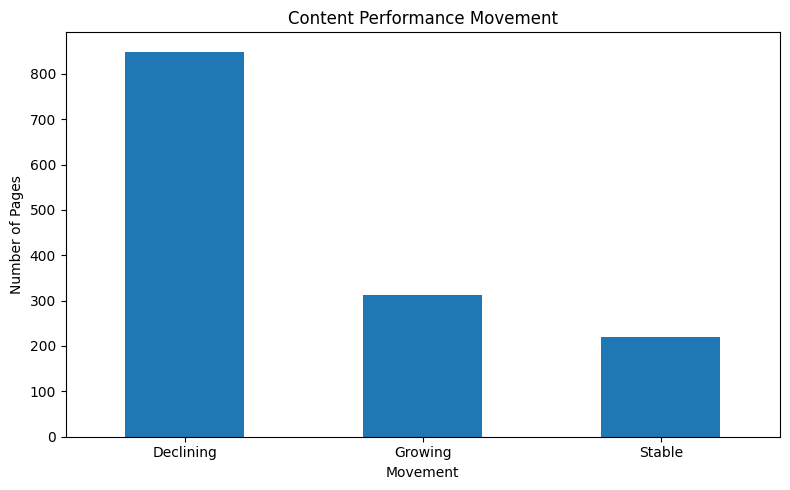

In [53]:
import matplotlib.pyplot as plt

# ============================================================
# EDA — Performance movement distribution
# ============================================================

movement_plot = (
    eda_df["movement"]
    .value_counts()
)

plt.figure(figsize=(8, 5))
movement_plot.plot(kind="bar")

plt.title("Content Performance Movement")
plt.xlabel("Movement")
plt.ylabel("Number of Pages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# EDA — impression momentum

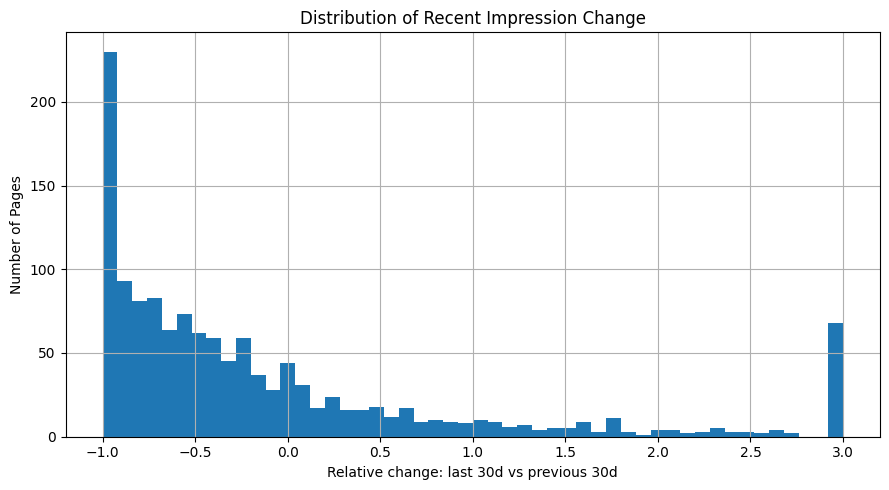

In [54]:
# ============================================================
# EDA — Impression change distribution
# ============================================================

plt.figure(figsize=(9, 5))

model_df["impression_change"].clip(
    lower=-1,
    upper=3
).dropna().hist(bins=50)

plt.title("Distribution of Recent Impression Change")
plt.xlabel("Relative change: last 30d vs previous 30d")
plt.ylabel("Number of Pages")

plt.tight_layout()
plt.show()

# EDA — CTR relationship

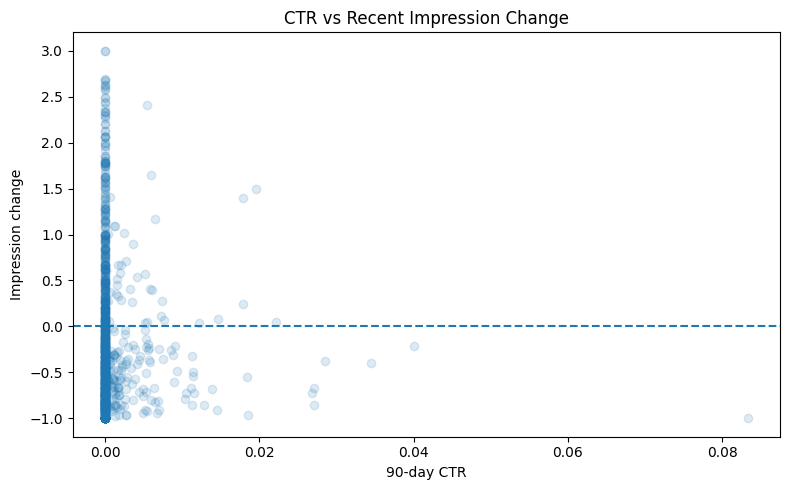

In [55]:
# ============================================================
# EDA — CTR vs impression change
# ============================================================

eda_sample = model_df[
    [
        "ctr_90d",
        "impression_change"
    ]
].dropna()

# Remove extreme values for readability
eda_sample = eda_sample[
    (eda_sample["ctr_90d"] >= 0) &
    (eda_sample["ctr_90d"] <= 1) &
    (eda_sample["impression_change"] >= -1) &
    (eda_sample["impression_change"] <= 3)
]

plt.figure(figsize=(8, 5))

plt.scatter(
    eda_sample["ctr_90d"],
    eda_sample["impression_change"],
    alpha=0.15
)

plt.axhline(0, linestyle="--")

plt.title("CTR vs Recent Impression Change")
plt.xlabel("90-day CTR")
plt.ylabel("Impression change")

plt.tight_layout()
plt.show()

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 5. Limitations

*What this work cannot claim.*

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.